In [23]:
import numpy as np
import pandas as pd
import scipy
import copy

import random

from src.simulation.domain.model import construct_well2, h_lim, betta_G_lim, construct_well
from src.simulation.service_layer.services import get_dict_for_data, build_plot, PlotData, Scale
from src.simulation.domain.meter import Meter, add_noise
from src.identification.domain.model import ident_values, identificate, get_data_by_slices, identificate_regul, \
    get_res_dict_for_ident, ident_values_nkt, identificate_nkt, ident_values_inflow, identificate_inflow
from src.identification.service_layer.services import calc_rsd_by_series, calc_bias_by_series, calc_error

In [24]:
# Начальные условия
M_q = 0.5
epsilon = 0.00001
K_NUMBERS = 45000  # Количество точек моделирования
dt = 0.0001  # Суток

w_program = {1.1: 1.065556, 2.2: 0.75, 3: 1}

well = construct_well2(agzu_on=False, p_L_change_on=False, nn1=0.8, nn2=0.9)
well.set_w_program(w_program)


df = well.simulate(K_NUMBERS, dt, M_q, epsilon, get_dict_for_data())
df = pd.DataFrame(df)
#df = df.iloc[10000:].reset_index(drop=True)

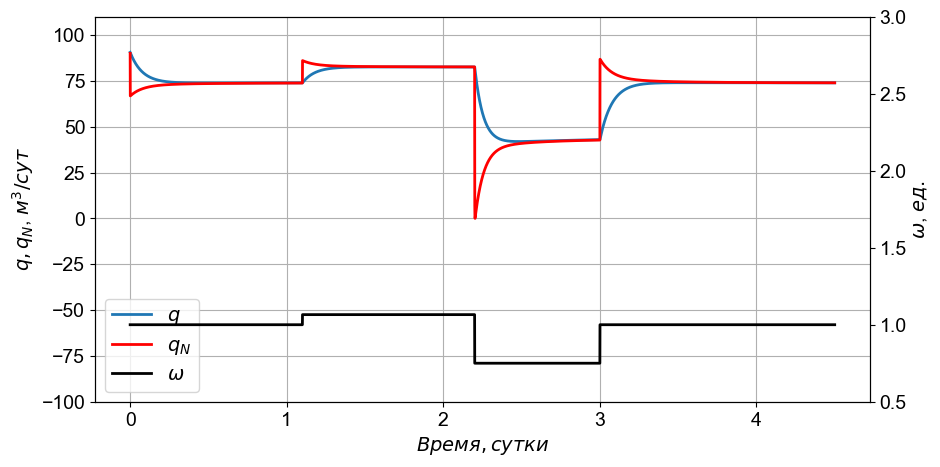

In [26]:
plot_data = [
             {'data': (
                PlotData(df['q'], '', 2, 'q'),
                PlotData(df['q_N'], 'r', 2, 'q_N'),
              ), 'x': df['x'], 'y_scale': Scale(min=-100, max=110), 'dt': dt, 'mu': 'м^3/сут'},
             {'data': (
               PlotData(df['u'], 'k', 2, '\omega'),
               #PlotData(df['agzu'], 'g', 1, 'АГЗУ'),
              ), 'x': df['x'], 'y_scale': Scale(min=0.5, max=3), 'dt': dt, 'mu': 'ед.'},
            ]

plot = build_plot(plot_data)
plot.show()

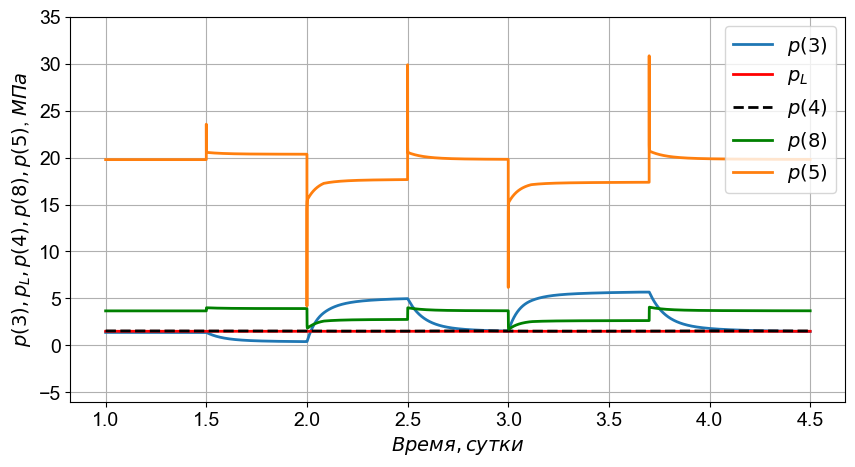

In [4]:
plot_data = [
            {'data': (
              PlotData(df['p_3'], '', 2, 'p(3)'),
              PlotData(df['p_L'], 'r', 2, 'p_L'),
              PlotData(df['p_4'], '--k', 2, 'p(4)'),
              PlotData(df['p_8'], 'g', 2, 'p(8)'),
              PlotData(df['p_5'], '', 2, 'p(5)'),
              ), 'x': df['x'], 'y_scale': Scale(min=-6, max=35), 'dt': dt, 'mu': 'МПа'},


]


plot = build_plot(plot_data)
plot.show()

In [5]:
meter = Meter(dt)
meter.noise_enable = False
meter.noise_amplitude = 0

ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

calc_df = ident_values_nkt(ident_k, ident_dt, df_ident, well, filter_name=None)

b, squared_error_sum = identificate_nkt(calc_df, ident_k)
b

array([6.49917253, 1.02972594, 0.96087827])

In [6]:
# Иерархичная идентификация

experiment_num_max = 5

t_N_experiment = np.linspace(0.45*well.pump.t_N, 2.5*well.pump.t_N, experiment_num_max)
t_N_experiment.sort()

t_N_experiment = np.array(t_N_experiment)

t_N_calc = []
t_N_experiments_calc = []
r_N_calc = []


meter = Meter(dt)
meter.noise_enable = False
meter.noise_amplitude = 0

damping = 0.7
tol_t = 1e-7          # порог для t_N
t_N_best = None         # лучшее t_N с прошлой итерации

ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

for epoch in range(50):
    J = []

    res = {
        'r_N': np.zeros(experiment_num_max),
        'nn_1': np.zeros(experiment_num_max),
        'nn_2': np.zeros(experiment_num_max),
    }

    for experiment_num in range(experiment_num_max):

      well.pump.t_N = t_N_experiment[experiment_num]

      calc_df = ident_values_nkt(ident_k, ident_dt, df_ident, well, filter_name=None)

      b, squared_error_sum = identificate_nkt(calc_df, ident_k)

      res['r_N'][experiment_num] = b[0]
      res['nn_1'][experiment_num] = b[1]
      res['nn_2'][experiment_num] = b[2]

      J.append(squared_error_sum)


    X = np.array([[1]*experiment_num_max,
                  t_N_experiment,
                  -(0.5 * t_N_experiment**2),
                 ]).T

    y = np.array(J).T
    a, squared_error_sum, matrix_rank, SVD_ = scipy.linalg.lstsq(X, y)

    t_N = a[1]/(a[2])
    print(t_N)

    if epoch == 0:
        t_N_experiments_calc.append(copy.deepcopy(t_N_experiment))
        best_i = np.argmin(J)
        t_N_calc.append(t_N_experiment[best_i])
        r_N_calc.append(res['r_N'][best_i])

    if t_N_best is not None and abs(t_N - t_N_best) <= tol_t:
        break
    t_N_best = t_N

    t_N = a[1] / a[2]
    if t_N < t_N_experiment[0]:
        i = 0
    elif t_N > t_N_experiment[-1]:
        i = -1
    else:
        i = np.argmax(J)
    t_N_experiment[i] = (1 - damping) * t_N_experiment[i] + damping * t_N
    t_N_experiment.sort()

    t_N_experiments_calc.append(copy.deepcopy(t_N_experiment))
    t_N_calc.append(t_N)

    well.pump.t_N = t_N_best
    calc_df = ident_values_nkt(ident_k, ident_dt, df_ident, well, filter_name=None)
    b, squared_error_sum = identificate_nkt(calc_df, ident_k)
    r_N_calc.append(b[0])



0.0026149470919352162
0.002466337951967792
0.0015383576126192602
0.001829427843877387


KeyboardInterrupt: 

In [ ]:
well.pump.t_N = 0.02

In [ ]:
x_len = len(t_N_calc)
df = pd.DataFrame({'pots': t_N_experiments_calc, 't_N': t_N_calc, 'r_N': r_N_calc, 'x': list(range(x_len)),
                   't_N_model': [well.pump.t_N]* x_len, 'r_N_model': [well.pump.r_N]* x_len})

In [ ]:
plot_data = [

                 {'data': (

                PlotData(df['r_N'], 'r', 1, '\\hat{r_{N}}|\hat t_N'),
                PlotData(df['r_N_model'], '--', 2, 'r_{N}\ (модель)'),
              ), 'x': df['x'], 'y_scale': Scale(min=3.4, max=4.4), 'dt': dt, 'mu': 'сутки/м2'},
            ]

plot = build_plot(plot_data, x_label='Номер эксперимента')
plot.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
epochs = np.arange(len(t_N_experiments_calc))
t_min = np.array([g.min() for g in t_N_experiments_calc])
t_max = np.array([g.max() for g in t_N_experiments_calc])
fig, ax = plt.subplots(figsize=(9, 5))
# сужающийся диапазон
ax.fill_between(epochs, t_min, t_max, alpha=0.25, color='tab:blue', label='диапазон сетки $[t_{min}, t_{max}]$')
# все пробные точки
for k, grid in enumerate(t_N_experiments_calc):
    ax.scatter(np.full(len(grid), k), grid, s=25, alpha=0.6, color='tab:blue', zorder=3)
# минимум параболы / лучшая оценка t_N
ax.plot(epochs, df['t_N'].values[:len(epochs)], 'r', lw=1.5, label=r'$\hat t_N$')
# истинное значение
ax.axhline(well.pump.t_N, ls='--', color='k', label=r'$t_N$ (модель)')
ax.set_xlabel('Номер итерации')
ax.set_ylabel(r'$t_N$, сут')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Начальные условия
M_q = 0.5
epsilon = 0.00001
K_NUMBERS = 45000  # Количество точек моделирования
dt = 0.0001  # Суток

w_program = {2: 1.065556, 3: 0.9335, 3.7: 1}

well = construct_well2(agzu_on=False, p_L_change_on=False)
well.set_w_program(w_program)


df = well.simulate(K_NUMBERS, dt, M_q, epsilon, get_dict_for_data())
df = pd.DataFrame(df)

In [12]:
meter = Meter(dt)
meter.noise_enable = False
meter.noise_amplitude = 0

ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

calc_df = ident_values_inflow(ident_k, ident_dt, df_ident, well, filter_name=None)

b, squared_error_sum = identificate_inflow(calc_df, ident_k)
print({b[0]: well.reservoir.p_R,
       b[1]: well.reservoir.r_1,
       b[2]: well.reservoir.r_2,
       })

{np.float64(21.67346178695443): 21.65, np.float64(0.0833645209732295): 0.08333333333333333, np.float64(0.017073802724038523): 0.016666666666666666}


In [ ]:
# Иерархичная идентификация

experiment_num_max = 5

T_experiment = np.linspace(0.4*well.reservoir.T_2, 2*well.reservoir.T_2, experiment_num_max)
T_experiment.sort()

T_experiment = np.array(T_experiment)

T_R_calc = []
T_R_experiments_calc = []

p_R_calc = []
r_1_calc = []
r_2_calc = []


meter = Meter(dt)
meter.noise_enable = False
meter.noise_amplitude = 0

damping = 0.7
tol_t = 1e-5          # порог для t_N
T_R_best = None         # лучшее t_N с прошлой итерации

ident_dt, ident_k, df_ident = meter.measure(df, quant_step=None, denominator=1)

for epoch in range(50):
    J = []

    res = {
        'p_R': np.zeros(experiment_num_max),
        'r_1': np.zeros(experiment_num_max),
        'r_2': np.zeros(experiment_num_max),
    }

    for experiment_num in range(experiment_num_max):

      well.reservoir.T_2 = T_experiment[experiment_num]

      calc_df = ident_values_inflow(ident_k, ident_dt, df_ident, well, filter_name=None)

      b, squared_error_sum = identificate_inflow(calc_df, ident_k)

      res['p_R'][experiment_num] = b[0]
      res['r_1'][experiment_num] = b[1]
      res['r_2'][experiment_num] = b[2]

      J.append(float(np.sum(squared_error_sum)))


    X = np.array([[1]*experiment_num_max,
                  T_experiment,
                  -(0.5 * T_experiment**2),
                 ]).T

    y = np.array(J).T
    a, squared_error_sum, matrix_rank, SVD_ = scipy.linalg.lstsq(X, y)

    T_R = a[1]/(a[2])
    print(T_R)

    if epoch == 0:
        T_R_experiments_calc.append(copy.deepcopy(T_experiment))
        best_i = np.argmin(J)
        T_R_calc.append(T_experiment[best_i])

        p_R_calc.append(res['p_R'][best_i])
        r_1_calc.append(res['r_1'][best_i])
        r_2_calc.append(res['r_2'][best_i])

    if T_R_best is not None and abs(T_R - T_R_best) <= tol_t:
        break
    T_R_best = T_R

    T_R = a[1] / a[2]
    if T_R < T_experiment[0]:
        i = 0
    elif T_R > T_experiment[-1]:
        i = -1
    else:
        i = np.argmax(J)
    T_experiment[i] = (1 - damping) * T_experiment[i] + damping * T_R
    T_experiment.sort()

    T_R_experiments_calc.append(copy.deepcopy(T_experiment))
    T_R_calc.append(T_R)

    well.reservoir.T_2 = T_R_best
    calc_df = ident_values_inflow(ident_k, ident_dt, df_ident, well, filter_name=None)
    b, squared_error_sum = identificate_inflow(calc_df, ident_k)

    p_R_calc.append(b[0])
    r_1_calc.append(b[1])
    r_2_calc.append(b[2])



In [ ]:
well.reservoir.T_2 = 0.4
x_len = len(T_R_calc)
df = pd.DataFrame({'pots': T_R_experiments_calc, 'T_R': T_R_calc, 'p_R': p_R_calc,
                   'r_1': r_1_calc, 'r_2': r_2_calc, 'x': list(range(x_len)),
                   'T_R_model': [well.reservoir.T_2]* x_len, 'p_R_model': [well.reservoir.p_R]* x_len,
                   'r_1_model': [well.reservoir.r_1]* x_len, 'r_2_model': [well.reservoir.r_2]* x_len,
                   })

In [ ]:
plot_data = [
            {'data': (
                PlotData(df['p_R'], 'r', 1, '\\hat{P_{R}}|\hat T_R'),
                PlotData(df['p_R_model'], '--k', 2, 'P_{R}\ (модель)'),
              ), 'x': df['x'], 'y_scale': Scale(min=21.4, max=21.9), 'dt': dt, 'mu': 'сутки/м2'},

            ]

plot = build_plot(plot_data, x_label='Номер эксперимента')
plot.show()

In [ ]:
plot_data = [

            {'data': (
                PlotData(df['r_1'], 'r', 1, '\\hat{r_{1}}|\hat T_R'),
                PlotData(df['r_1_model'], '--k', 2, 'r_{1}\ (модель)'),
              ), 'x': df['x'], 'y_scale': Scale(min=0.08, max=0.09), 'dt': dt, 'mu': 'сутки/м2'},
                {'data': (
                PlotData(df['r_2'], '', 1, '\\hat{r_{2}}|\hat T_R'),
                PlotData(df['r_2_model'], '--', 2, 'r_{2}\ (модель)'),
              ), 'x': df['x'], 'y_scale': Scale(min=0.015, max=0.018), 'dt': dt, 'mu': 'сутки/м2'},

            ]

plot = build_plot(plot_data, x_label='Номер эксперимента')
plot.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
epochs = np.arange(len(T_R_experiments_calc))
t_min = np.array([g.min() for g in T_R_experiments_calc])
t_max = np.array([g.max() for g in T_R_experiments_calc])
fig, ax = plt.subplots(figsize=(9, 5))
# сужающийся диапазон
ax.fill_between(epochs, t_min, t_max, alpha=0.25, color='tab:blue', label='диапазон сетки $[T_{Rmin}, T_{Rmax}]$')
# все пробные точки
for k, grid in enumerate(T_R_experiments_calc):
    ax.scatter(np.full(len(grid), k), grid, s=25, alpha=0.6, color='tab:blue', zorder=3)
# минимум параболы / лучшая оценка t_N
ax.plot(epochs, df['T_R'].values[:len(epochs)], 'r', lw=1.5, label=r'$\hat T_R$')
# истинное значение
ax.axhline(well.reservoir.T_2, ls='--', color='k', label=r'$T_R$ (модель)')
ax.set_xlabel('Номер итерации')
ax.set_ylabel(r'$t_N$, сут')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()